<a href="https://colab.research.google.com/github/switlanakostyuk-ctrl/Apollo/blob/main/%D0%9F%D1%80%D0%BE%D0%B3%D0%BD%D0%BE%D0%B7%D1%83%D0%B2%D0%B0%D0%BD%D0%BD%D1%8F_%D0%BE%D1%80%D0%B5%D0%BD%D0%B4%D0%BD%D0%BE%D1%97_%D0%BF%D0%BB%D0%B0%D1%82%D0%B8_%D0%B7%D0%B0_%D0%B6%D0%B8%D1%82%D0%BB%D0%BE_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання: Прогнозування орендної плати за житло

## Мета завдання
Застосувати знання з лекції для побудови моделі лінійної регресії, що прогнозує орендну плату за житло в Індії. Ви пройдете весь цикл вирішення задачі машинного навчання: від дослідницького аналізу до оцінки якості моделі.

## Опис датасету
**House Rent Prediction Dataset** містить інформацію про 4700+ оголошень про оренду житла в Індії з такими параметрами:
- **BHK**: Кількість спалень, залів, кухонь
- **Rent**: Орендна плата (цільова змінна)
- **Size**: Площа в квадратних футах
- **Floor**: Поверх та загальна кількість поверхів
- **Area Type**: Тип розрахунку площі
- **Area Locality**: Район
- **City**: Місто
- **Furnishing Status**: Стан меблювання
- **Tenant Preferred**: Тип орендаря
- **Bathroom**: Кількість ванних кімнат
- **Point of Contact**: Контактна особа

---

## Завдання 1: Завантаження та перший огляд даних (1 бал)

**Що потрібно зробити:**
1. Завантажте дані з файлу `House_Rent_Dataset.csv`
2. Виведіть розмір датасету
3. Покажіть перші 5 рядків
4. Виведіть загальну інформацію про дані (включно з типами даних та кількістю значень)


In [231]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [232]:
# Завантажуємо дані
df = pd.read_csv('House_Rent_Dataset.csv', sep=None, engine='python')

# Перше знайомство з даними
df.shape

(4746, 12)

In [233]:
df.head(3)

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner


In [234]:
# аналіз
df.shape
df.head()
df.info()

# обробка
df = df.drop_duplicates()
df = df.dropna(subset=['Rent', 'Size'])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Posted On          4746 non-null   object
 1   BHK                4746 non-null   int64 
 2   Rent               4746 non-null   int64 
 3   Size               4746 non-null   int64 
 4   Floor              4746 non-null   object
 5   Area Type          4746 non-null   object
 6   Area Locality      4746 non-null   object
 7   City               4746 non-null   object
 8   Furnishing Status  4746 non-null   object
 9   Tenant Preferred   4746 non-null   object
 10  Bathroom           4746 non-null   int64 
 11  Point of Contact   4746 non-null   object
dtypes: int64(4), object(8)
memory usage: 445.1+ KB


In [235]:
rent_stats = df['Rent'].describe()         # весь діапазон цін
print(rent_stats)

count    4.746000e+03
mean     3.499345e+04
std      7.810641e+04
min      1.200000e+03
25%      1.000000e+04
50%      1.600000e+04
75%      3.300000e+04
max      3.500000e+06
Name: Rent, dtype: float64


In [236]:

df_clean['log_rent'] = np.log1p(df_clean['Rent'])

px.histogram(df_clean, x='log_rent', nbins=100,
             title='Логарифмований Rent після очищення').show()

In [237]:
import plotly.io as pio
pio.renderers.default = 'colab'

In [238]:
df_final = df.copy()
df_final['log_rent'] = np.log1p(df_final['Rent'])

fig = px.histogram(df_final, x="log_rent", nbins=100,
                   title="Справжній логарифмічний розподіл вартості оренди",
                   color_discrete_sequence=['indianred'])

fig.update_layout(xaxis_title="Логарифм ціни (log_rent)",
                  yaxis_title="Кількість квартир")
fig.show()

Тут вже чітко видно що є один викид. Це нерухомість з ціною 3,51млн. Найбільша кількість будинків є у діапазоні 10-20тис.

## Завдання 2: Дослідницький аналіз даних (EDA) (5 балів)

**Що потрібно зробити:**
1. **Аналіз пропущених значень.** Перевірте наявність і відсоток пропущених значень у кожній колонці
2. **Базова статистика.** Обчисліть базову статистику (середнє, квартилі, стандартне відхилення) для числових змінних.
3. **Аналіз цільової змінної.** Побудуйте гістограму розподілу цільової змінної (Rent)
4. **Робота з викидами.** Знайдіть та видаліть викиди в цільовій змінній (якщо є). Визначити викиди можна будь-яким зрозумілим для вас способом, як варіант - таким, що використовується в побудові box-plot (https://en.wikipedia.org/wiki/Box_plot#Example_with_outliers).
5. **Аналіз категоріальних змінних.** Виведіть кількість унікальних значень для кожної з категоріальних колонок.


In [239]:
# Аналіз пропущених значень
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100

missing_percent

,0
Posted On,0.0
BHK,0.0
Rent,0.0
Size,0.0
Floor,0.0
Area Type,0.0
Area Locality,0.0
City,0.0
Furnishing Status,0.0
Tenant Preferred,0.0


Аналіз показав, що пропущені значення в датасеті відсутні (0% у всіх колонках), тому додаткова обробка пропусків або заповнення медіаною не потрібні

In [240]:
# Базова статистика
display(df.describe().round(2))

,BHK,Rent,Size,Bathroom
count,4746.00,4746.00,4746.00,4746.00
mean,2.08,34993.45,967.49,1.97
std,0.83,78106.41,634.20,0.88
min,1.00,1200.00,10.00,1.00
25%,2.00,10000.00,550.00,1.00
50%,2.00,16000.00,850.00,2.00
75%,3.00,33000.00,1200.00,2.00
max,6.00,3500000.00,8000.00,10.00


### Аналіз цільової змінної (Rent)

In [241]:
px.histogram(
    df,
    x='Rent',
    nbins=100,
    title='Розподіл цільової змінної (Rent)').show()

Графік має правосторонній скос.Через викиди модель гірше навчиться і буде помилкво завищувати вартість звичайного житла. Тому треба видаляти викиди.

### НОРМАЛІЗУВАТИ РОЗПОДІЛ ЧЕРЕЗ ЛОГАРИФМ

In [242]:
df['log_rent'] = np.log1p(df['Rent'])

px.histogram(df, x='log_rent', nbins=100,
             title='Логарифмований Rent').show()

Логарифмування зменшує вплив великих значень та робить розподіл більш симетричним, що покращує якість лінійної моделі.

Видалення викидів:

In [243]:
Q1 = df['Rent'].quantile(0.25)
Q3 = df['Rent'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

df_clean = df[(df['Rent'] >= lower_bound) & (df['Rent'] <= upper_bound)]

# перевірка
print("Було:", df.shape)
print("Стало:", df_clean.shape)

Lower bound: -24500.0
Upper bound: 67500.0
Було: (4746, 13)
Стало: (4226, 13)


ПЕРЕВІРКА ПІСЛЯ ВИДАЛЕННЯ ВИКИДІВ

In [244]:
px.histogram(df_clean, x='Rent', nbins=100,
             title='Розподіл Rent після видалення викидів').show()

ЛОГАРИФМУВАННЯ НА ОЧИЩЕНИХ ДАНИХ

In [245]:
df_clean.loc[:, 'log_rent'] = np.log1p(df_clean['Rent'])

px.histogram(df_clean, x='log_rent', nbins=100,
             title='Логарифмований Rent після очищення').show()

Після застосування логарифмічного перетворення розподіл став більш симетричним і наближеним до нормального. Це спрощує навчання лінійної регресії та зменшує вплив великих значень.

In [246]:
#АНАЛІЗ КАТЕГОРІАЛЬНИХ ЗМІННИХ
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    print(col, df[col].nunique())

Posted On 81
Floor 480
Area Type 3
Area Locality 2235
City 6
Furnishing Status 3
Tenant Preferred 3
Point of Contact 3



## Завдання 3: Аналіз кореляцій та взаємозв'язків (3 бали)

**Що потрібно зробити:**
1. Обчисліть матрицю кореляцій для числових змінних
2. Візуалізуйте кореляційну матрицю за допомогою heatmap
3. Побудуйте scatter plot між Size та Rent
4. Проаналізуйте взаємозв'язок між BHK та Rent за допомогою boxplot (який розподіл плати для різних значень BHK)


МАТРИЦЯ КОРЕЛЯЦІЙ ДЛЯ ЧИСЛОВИХ ЗМІННИХ

In [247]:
import plotly.express as px

num_df = df_clean.select_dtypes(include='number')

# матриця кореляцій
corr = num_df.corr()

fig = px.imshow(
    corr,
    text_auto='.2f',
    color_continuous_scale='RdBu_r',
    title='Кореляція між характеристиками нерухомості',
    labels=dict(color="Кореляція"))

fig.update_layout(height=500)
fig.show()

In [248]:
df_clean.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact,log_rent
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner,9.210440
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner,9.903538
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner,9.741027
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner,9.210440
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner,8.922792


ІНТЕРПРЕПАЦІЯ КОРЕЛЯЦІЇ

Найвищу кореляцію з цільовою змінною мають Size, BHK та Bathroom, що вказує на їх сильний лінійний зв’язок із ціною оренди. Це робить їх ключовими кандидатами для побудови лінійної моделі.

## Як площа впливає на оренду?

In [249]:
px.scatter(df_clean, x='Size', y='Rent', title='Залежність ціни від площі (без викидів)', trendline="ols").show()

ОТЖЕ: Для малих квартир ціна росте повільно, а відносно збільшення площі розкид цін стає набагато більшим.

## Взаємозв'язок між BHK та Rent за допомогою boxplot (який розподіл плати для різних значень BHK):

In [250]:
px.box(
    df_clean,
    x='BHK',  y='Rent',
    title='Залежність орендної плати від кількості кімнат',
    labels={
        'BHK': 'Кількість кімнат',
        'Rent': 'Орендна плата' } ).show()

Зі збільшенням кількості кімнат медіанна вартість оренди стабільно зростає, що підтверджує BHK як один з ключових факторів ціноутворення.
Чим більше кімнат у квартирі, тим вищим стає ящик. Це каже, що ринок багатокімнатних квартир набагато різноманітніший за ціною, ніж ринок однокімнатних.

## Завдання 4: Feature Engineering та підготовка даних (4 бали)

**Що потрібно зробити:**
1. Закодуйте категоріальні змінні за допомогою One-Hot Encoding. Пригадайте, що в лекції ми говорили щодо кодування кат. змінних з великої кількістю різних значень і як працювати з такими випадками. Ви можете закодувати не всі кат. змінні, а лише ті, що вважаєте за потрібні (скажімо ті, що мають відносно небагато різних значень).
2. **Опціонально (по 0.5 бала за кожну доцільну ознаку):** Додайте нові ознаки, обчислені на основі наявних даних, які б на ваш погляд були корисними для моделі
3. Виберіть ознаки для побудови моделі (виключіть непотрібні колонки). Виключити можна, наприклад, ті колонки, які мають категоріальний тип і забагато (більше 20) різних значень. Треба виключити хоча б 1 колонку.
4. Розділіть дані на ознаки (X) та цільову змінну (y)
5. Застосуйте стандартизацію до числових ознак


In [251]:
# Видалити зайві колонки
cols_to_drop = ['Posted On', 'Floor', 'Area Locality', 'Point of Contact']
df_model = df_clean.drop(columns=cols_to_drop)

In [252]:
# One-Hot Encoding
df_encoded = pd.get_dummies(
    df_model,
    columns=['Area Type', 'City', 'Furnishing Status', 'Tenant Preferred'],
    drop_first=True)

In [253]:
# Розділення на X та y
X = df_encoded.drop('Rent', axis=1)
y = np.log1p(df_encoded['Rent'])

Закодувала категоріальні змінні, прибрала зайві колонки та підготувала дані для моделі. Цільову змінну трохи “згладила” через логарифм. Далі потрібно буде стандартизувати числові ознаки після поділу на train і test, щоб уникнути витоку даних.

## Завдання 5: Розділення даних та навчання моделі (3 бали)

**Що потрібно зробити:**
1. Розділіть дані на навчальну (80%) та тестову (20%) вибірки.
2. Створіть модель лінійної регресії.
3. Навчіть модель на навчальних даних.
4. Виведіть усі коефіцієнти моделі (ваги) та напишіть, які 2 ознаки найбільше впливають на прогноз.
5. Зробіть прогнози на тренувальній та тестовій вибірках.

In [254]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
import pandas as pd

X = df.drop(columns=['Rent', 'log_rent', 'Posted On'], errors='ignore')
y = df['Rent']
X = X.select_dtypes(include=['int64', 'float64'])

# Розділення на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42 )


# Стандартизація числових ознак
num_cols = ['BHK', 'Size', 'Bathroom']

scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols].astype(float))
X_test[num_cols] = scaler.transform(X_test[num_cols].astype(float))

In [255]:
# Створення та навчання
model = LinearRegression()
model.fit(X_train, y_train)

# Оцінка якості R²
r2_train = model.score(X_train, y_train)
r2_test = model.score(X_test, y_test)

print("Train R2:", round(r2_train, 3))
print("Test R2:", round(r2_test, 3))

# Коефіцієнти моделі
coef_df = pd.Series(model.coef_, index=X_train.columns)
coef_df = coef_df.sort_values(key=abs, ascending=False)

print("\nВаги моделі:")
print(coef_df)

print("\nТоп-2 найважливіші ознаки:")
print(coef_df.head(2))

# Прогнози
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

print("\nПерші 5 прогнозів на тестовій вибірці:")
print(y_test_pred[:5])

Train R2: 0.189
Test R2: 0.359

Ваги моделі:
Bathroom    24485.060075
Size        13370.539127
BHK          -225.713612
dtype: float64

Топ-2 найважливіші ознаки:
Bathroom    24485.060075
Size        13370.539127
dtype: float64

Перші 5 прогнозів на тестовій вибірці:
[ 38847.26924706  32531.08702748  26593.87574107  74624.2770092
 145348.0495243 ]


Модель пояснює лише частину варіації орендної плати, тобто її якість є невисокою. При цьому значення R² на тестовій вибірці є вищим, ніж на тренувальній, що може свідчити про нестабільність моделі або випадковий розподіл даних.

Аналіз коефіцієнтів показав, що найбільший вплив на прогноз мають кількість ванних кімнат і площа житла.
 Це логічно, оскільки більша площа та більша кількість ванних кімнат зазвичай підвищують вартість оренди.

Загалом модель здатна вловлювати базові залежності, однак її точність є недостатньою, що може бути пов’язано з  відсутністю важливих ознак (наприклад, район або інфраструктура), наявністю нелінійних залежностей у даних чи обмеженнями самої лінійної регресії.

## Завдання 6: Оцінка якості моделі (2 бали)

**Що потрібно зробити:**
1. Обчисліть MAE, RMSE та R² для навчальної та тестової вибірок
2. Порівняйте метрики та зробіть висновок про якість моделі
3. Проаналізуйте і дайте висновок, чи є ознаки перенавчання або недонавчання (**Нагадування**: перенавчання - коли модель дуже добре працює на тренувальних даних, але погано на тестових; недонавчання - коли модель погано працює навіть на тренувальних даних)
4. Побудуйте графік розсіювання "реальні vs прогнозовані значення" та зробіть висновок про якість моделі


In [256]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def metrics(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred) }

train_metrics = metrics(y_train, y_train_pred)
test_metrics = metrics(y_test, y_test_pred)

print("Train metrics:", train_metrics)
print("Test metrics:", test_metrics)

Train metrics: {'MAE': 27760.96435881091, 'RMSE': np.float64(73323.61276476875), 'R2': 0.18887239681731494}
Test metrics: {'MAE': 26191.957939858174, 'RMSE': np.float64(50544.78981107286), 'R2': 0.35896327760736757}


In [257]:
fig = px.scatter(
    x=y_test,
    y=y_test_pred,
    labels={'x': 'Реальні', 'y': 'Прогноз'},
    title='Реальні vs Прогнозовані' )

# ідеальна лінія
min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())

fig.add_shape(
    type='line',
    x0=min_val,   y0=min_val,
    x1=max_val,  y1=max_val,
    line=dict(color='red', dash='dash') )

fig.show()

Червона лінія — це лінія ідеальних прогнозів.

Модель загалом добре прогнозує значення, оскільки більшість точок близькі до лінії ідеальних передбачень. Проте для великих значень похибка трохи зростає.

## Завдання 7: Аналіз помилок (4 бали)

**Що потрібно зробити:**
1. Обчисліть помилки (residuals = реальні - прогнозовані значення)
2. Побудуйте гістограму розподілу помилок
3. Створіть scatter plot помилок відносно величини прогнозованих значень. Чи росте помилка з ростом прогнозованого значення?
4. Знайдіть 5 прогнозів з найбільшими помилками
5. Проаналізуйте, на яких типах житла модель помиляється найбільше. Типи можна розрізняти за кількістю кімнат чи містом, наприклад.
6. Подумайте і напишіть, які наступні кроки ви б зробили, аби поліпшити якість моделі. Опціонально можна їх зробити і ми перевіримо :)

In [258]:
import matplotlib.pyplot as plt

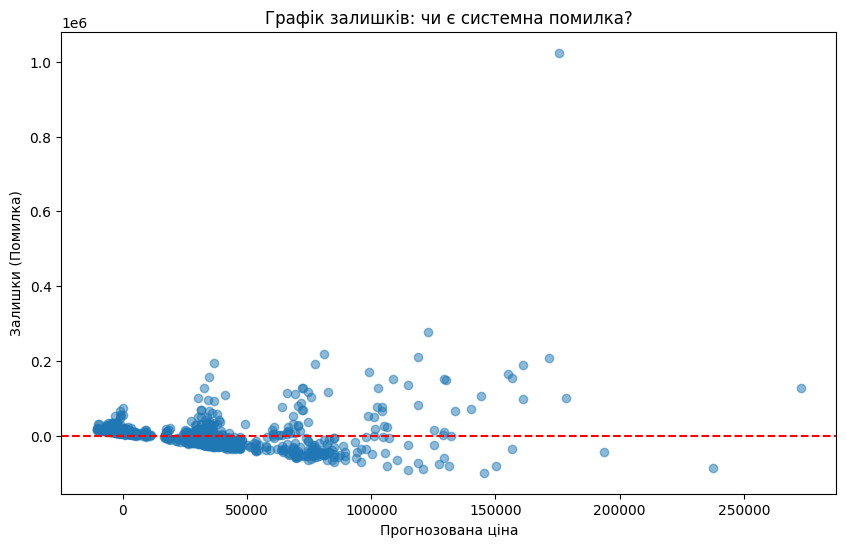

In [259]:
plt.figure(figsize=(10, 6))
residuals = y_test - y_test_pred
plt.scatter(y_test_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Прогнозована ціна')
plt.ylabel('Залишки (Помилка)')
plt.title('Графік залишків: чи є системна помилка?')
plt.show()

Графік залишків показує, що помилки моделі зростають разом із ціною та не є випадковими. Це означає, що модель працює нестабільно, особливо для дорогого житла, і має систематичні помилки. Загалом модель добре працює для об’єктів середнього сегменту, значно гірше прогнозує дешеве та дороге житло, не враховує складні залежності.

In [260]:
px.histogram(residuals, nbins=50, title='Розподіл помилок').show()

Розподіл має позитивну асиметрію - довгий правий хвіст. Це означає, що модель частіше схильна сильно "недооцінювати" певні об'єкти, ніж сильно їх "переоцінювати".

# Scatter помилок

In [261]:
px.scatter(x=y_test_pred, y=residuals,
           labels={'x': 'Прогноз', 'y': 'Помилка'},
           title='Помилки vs прогноз').show()

Так, помилка росте. При збільшенні прогнозованої вартості розкид точок стає набагато ширшим.

Модель демонструє нелінійний вигин: на малих значеннях вона помиляється в один бік, на середніх працює точно, а на високих — знову помиляється. Лінійна регресія занадто проста для цих даних.

In [262]:
errors_df = X_test.copy()
errors_df['real'] = y_test
errors_df['pred'] = y_test_pred
errors_df['error'] = abs(errors_df['real'] - errors_df['pred'])

In [263]:
top_errors = errors_df.sort_values(by='error', ascending=False).head(5)

for index, row in top_errors.iterrows():
    # тип помилки
    if row['pred'] < 0:
        type_error = "Абсурдний від'ємний прогноз"
    else:
        type_error = "Недооцінка об'єкта"

    error_k = round(row['error'] / 1000, 1)

    print(f"{type_error} №{index} (промах на ~{error_k}k)")

Недооцінка об'єкта №1001 (промах на ~1024.3k)
Недооцінка об'єкта №1344 (промах на ~277.0k)
Недооцінка об'єкта №1084 (промах на ~219.1k)
Недооцінка об'єкта №3148 (промах на ~211.2k)
Недооцінка об'єкта №1718 (промах на ~208.3k)


Системна проблема полягає у недооцінці дорогмх об’єктів і “тягне” прогнози до середнього рівня, погано працюючи з дорогим сегментом. Звичайних квартир більше, тому модель добре відтворює “середній ринок”, але не розуміє, що саме робить об’єкти дорогими, і оцінює їх як трохи кращі за середні.

Подивитись закономірності:

In [264]:
top_errors[['real', 'pred', 'BHK', 'Size', 'Bathroom'] +
           [col for col in top_errors.columns if 'City_' in col]].T

,1001,1344,1084,3148,1718
real,1.200000e+06,400000.000000,300000.000000,330000.000000,380000.000000
pred,1.756685e+05,123033.649210,80940.459229,118837.552546,171712.152981
BHK,2.276978e+00,2.276978,1.084619,1.084619,2.276978
Size,6.350419e+00,2.413790,1.311534,4.145907,3.988442
Bathroom,2.292108e+00,2.292108,1.163887,1.163887,3.420329


# ВИСНОВОК

Щоб покращити якість моделі, доцільно почати не зі зміни алгоритму, а з удосконалення набору ознак (feature engineering), оскільки модель обмежена недостатньою кількістю інформації про об’єкти.

Першим кроком може бути створення нових інформативних ознак. Наприклад, можна додати ціну за квадратний метр, що дозволяє краще оцінювати “якість” житла незалежно від його розміру. Також можна створити категоріальну ознаку сегменту житла (дешеве, середнє, дороге), що допоможе моделі краще розрізняти різні типи об’єктів. При цьому важливо уникати витоку цільової змінної при побудові таких ознак.

Другим важливим напрямком є робота з викидами, зокрема з дуже дорогими об’єктами. Вони зустрічаються рідко, але мають непропорційно великий вплив на модель, що може викривляти загальні закономірності. У деяких випадках доцільно обмежити їх вплив або розглянути окремо.

Після покращення ознак можна перейти до використання більш складних моделей, таких як Random Forest або Gradient Boosting, які краще працюють із нелінійними залежностями та складними взаємодіями між змінними.

У підсумку проблема тут не стільки в самій моделі, скільки в тому, що вона намагається пояснити складний ринок дуже обмеженим набором факторів. Покращення feature engineering та якісна обробка даних можуть значно підвищити точність навіть без зміни моделі.
